## Data Preparation

In [2]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
from collections import Counter

# Natural Language Processing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load the dataset
file_path = '/content/drive/MyDrive/tci data/sentimentdataset.csv'
df = pd.read_csv(file_path)

# Clean column names and initial inspection
df.columns = df.columns.str.strip()
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Loaded: 732 rows, 15 columns


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [5]:
# Cleaning text data
df['Text'] = df['Text'].str.strip().str.lower()
df['Sentiment'] = df['Sentiment'].str.strip().str.lower()

# Mapping 200+ unique sentiments into 3 categories for better model performance
def simplify_sentiment(sentiment):
    pos = ['joy', 'happy', 'love', 'excited', 'content', 'peaceful']
    neg = ['sad', 'angry', 'fear', 'anxious', 'bitter', 'lonely']
    if any(word in sentiment for word in pos): return 2 # Positive
    if any(word in sentiment for word in neg): return 0 # Negative
    return 1 # Neutral

df['Label'] = df['Sentiment'].apply(simplify_sentiment)
print("Distribution after mapping:")
print(df['Label'].value_counts())

Distribution after mapping:
Label
1    619
2     88
0     25
Name: count, dtype: int64


In [6]:
# Sentiment distribution
sentiment_counts = df['Sentiment'].value_counts()
sentiment_percentages = (sentiment_counts / len(df)) * 100

print('Sentiment Distribution:')
print('='*50)
for sentiment, count in sentiment_counts.head(15).items():
    pct = sentiment_percentages[sentiment]
    print(f'{sentiment:20s}: {count:4d} ({pct:5.2f}%)')

print(f'\nTotal unique sentiments: {len(sentiment_counts)}')

Sentiment Distribution:
positive            :   45 ( 6.15%)
joy                 :   44 ( 6.01%)
excitement          :   37 ( 5.05%)
contentment         :   19 ( 2.60%)
neutral             :   18 ( 2.46%)
gratitude           :   18 ( 2.46%)
curiosity           :   16 ( 2.19%)
serenity            :   15 ( 2.05%)
happy               :   14 ( 1.91%)
despair             :   11 ( 1.50%)
nostalgia           :   11 ( 1.50%)
hopeful             :    9 ( 1.23%)
loneliness          :    9 ( 1.23%)
awe                 :    9 ( 1.23%)
grief               :    9 ( 1.23%)

Total unique sentiments: 191


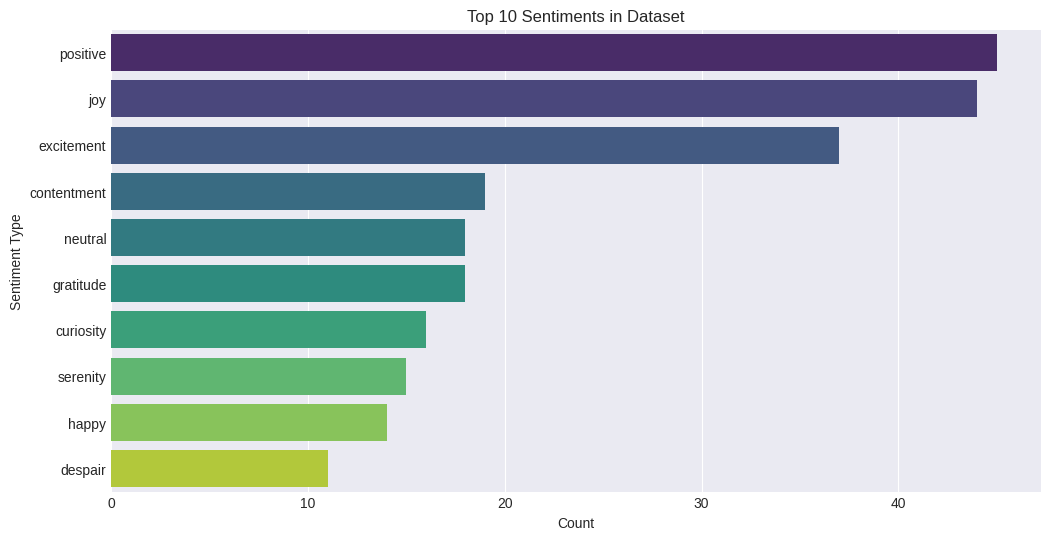

In [7]:
#Visualize Top 10 Sentiments
plt.figure(figsize=(12, 6))
top_sentiments = df['Sentiment'].value_counts().head(10)
sns.barplot(x=top_sentiments.values, y=top_sentiments.index, palette='viridis')
plt.title('Top 10 Sentiments in Dataset')
plt.xlabel('Count')
plt.ylabel('Sentiment Type')
plt.savefig('top_sentiments.png')
plt.show()

Platform Distribution:
Platform
Instagram     258
Facebook      231
Twitter       128
Twitter       115
Name: count, dtype: int64


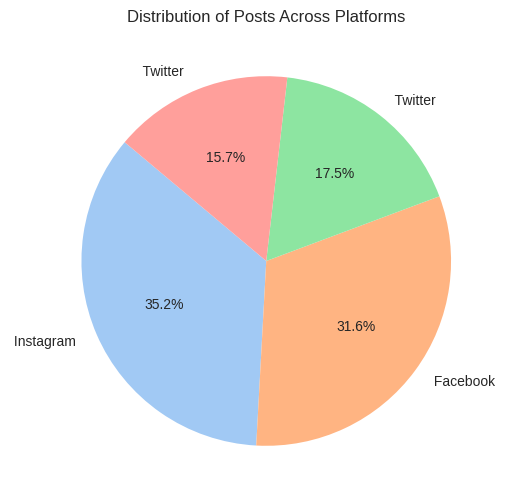

In [8]:
# Platform Distribution
platform_counts = df['Platform'].value_counts()

print('Platform Distribution:')
print(platform_counts)

plt.figure(figsize=(10, 6))
platform_counts = df['Platform'].value_counts()
plt.pie(platform_counts, labels=platform_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Posts Across Platforms')
plt.savefig('platform_distribution.png')
plt.show()

Average Engagement by Top 10 Sentiments:
             Likes  Retweets
Sentiment                   
contentment  51.37     25.79
excitement   50.27     25.49
joy          49.27     24.70
gratitude    49.17     24.56
happy        45.14     23.07
curiosity    43.00     21.50
serenity     42.40     21.13
neutral      40.50     20.56
positive     37.78     18.87
despair      35.64     17.91


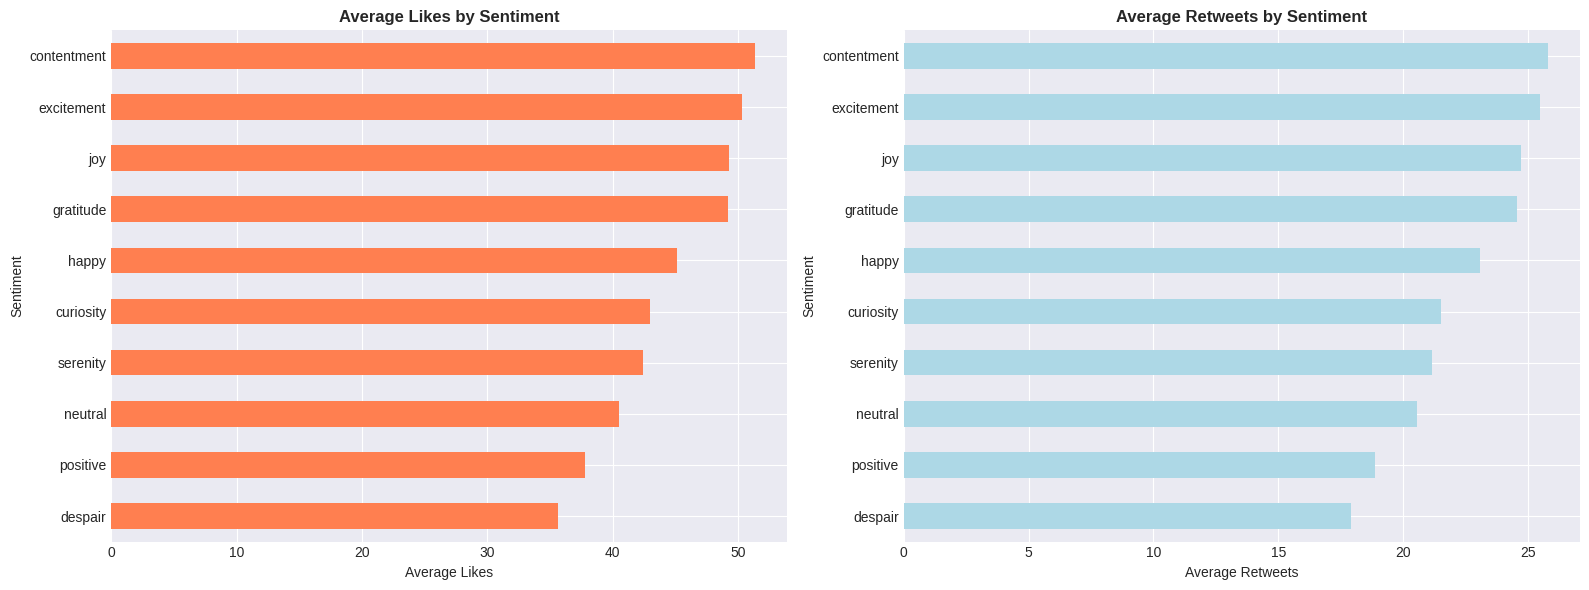

In [9]:
sentiment_counts = df['Sentiment'].value_counts()
top_10_sentiments = sentiment_counts.head(10).index
df_top10 = df[df['Sentiment'].isin(top_10_sentiments)]

engagement_by_sentiment = df_top10.groupby('Sentiment')[['Likes', 'Retweets']].mean().sort_values('Likes', ascending=False)

print('Average Engagement by Top 10 Sentiments:')
print(engagement_by_sentiment.round(2))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

engagement_by_sentiment['Likes'].plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Average Likes by Sentiment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Likes')
axes[0].invert_yaxis()

engagement_by_sentiment['Retweets'].plot(kind='barh', ax=axes[1], color='lightblue')
axes[1].set_title('Average Retweets by Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Retweets')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

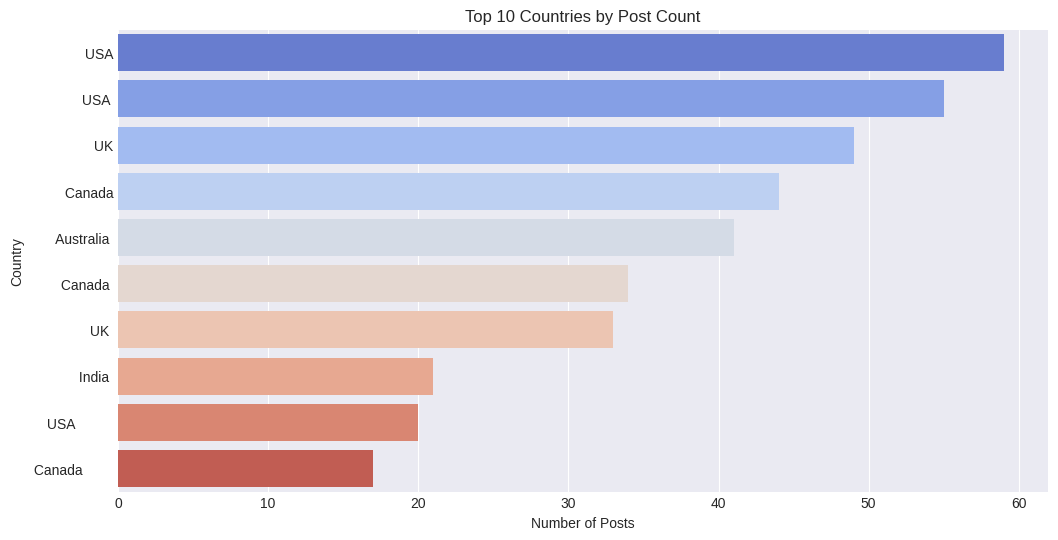

In [10]:
#Top Countries by Post Count
plt.figure(figsize=(12, 6))
top_countries = df['Country'].value_counts().head(10)
sns.countplot(data=df[df['Country'].isin(top_countries.index)], y='Country',
              order=top_countries.index, palette='coolwarm')
plt.title('Top 10 Countries by Post Count')
plt.xlabel('Number of Posts')
plt.savefig('top_countries.png')
plt.show()

# Model Training

## Create training/validation/test splits

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Embedding, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def map_sentiment(sentiment):
    sentiment = str(sentiment).lower()
    pos_words = ['joy', 'happy', 'excited', 'love', 'content', 'grateful', 'peaceful', 'hopeful']
    neg_words = ['sad', 'angry', 'fear', 'anxious', 'bitter', 'disappointed', 'lonely', 'grief']

    if any(word in sentiment for word in pos_words): return 2 # Positive
    if any(word in sentiment for word in neg_words): return 0 # Negative
    return 1 # Neutral

df['Sentiment_Group'] = df['Sentiment'].apply(map_sentiment)

# Step 2: Text Vectorization
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X = tfidf.fit_transform(df['Text']).toarray()
y = df['Sentiment_Group'].values

# Sequence Tokenization (Specifically for RNN/LSTM)
max_words = 2000
max_len = 50
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['Text'])
sequences = tokenizer.texts_to_sequences(df['Text'])
X_seq = pad_sequences(sequences, maxlen=max_len)

# Split data (70% Train, 30% Test)
X_train_tf, X_test_tf, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_seq, X_test_seq, _, _ = train_test_split(X_seq, y, test_size=0.3, random_state=42)

## Artificial Neural Network (Multilayer Perceptron)

In [12]:
from sklearn.neural_network import MLPClassifier

print("--- Model 1: ANN (MLP) Evaluation ---")
mlp_params = {
    'hidden_layer_sizes': [(64,), (128, 64)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'lbfgs']
}
grid_mlp = GridSearchCV(MLPClassifier(max_iter=500, random_state=42), mlp_params, cv=3, scoring='accuracy')
grid_mlp.fit(X_train_tf, y_train)

ann_preds = grid_mlp.predict(X_test_tf)
ann_model = grid_mlp.best_estimator_

# Results of all the different configurations
results_df = pd.DataFrame(grid_mlp.cv_results_)
performance_summary = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
print(performance_summary.sort_values(by='rank_test_score'))

print("Performance of the best MLP model: ")
print(classification_report(y_test, ann_preds))
print("Best Hyperparamater Configuration:", grid_mlp.best_params_)

--- Model 1: ANN (MLP) Evaluation ---
                                              params  mean_test_score  \
7  {'activation': 'tanh', 'hidden_layer_sizes': (...         0.841784   
1  {'activation': 'relu', 'hidden_layer_sizes': (...         0.839846   
5  {'activation': 'tanh', 'hidden_layer_sizes': (...         0.837908   
3  {'activation': 'relu', 'hidden_layer_sizes': (...         0.835959   
4  {'activation': 'tanh', 'hidden_layer_sizes': (...         0.822280   
6  {'activation': 'tanh', 'hidden_layer_sizes': (...         0.818369   
2  {'activation': 'relu', 'hidden_layer_sizes': (...         0.816397   
0  {'activation': 'relu', 'hidden_layer_sizes': (...         0.812499   

   std_test_score  rank_test_score  
7        0.021971                1  
1        0.026278                2  
5        0.027047                3  
3        0.020649                4  
4        0.006945                5  
6        0.008038                6  
2        0.005790                7  
0       

## Fuzzy Classifier

In [13]:
!pip install -U scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 39.6 MB/s eta 0:00:00


In [14]:
import numpy as np
import skfuzzy as fuzz
from sklearn.metrics import classification_report

print("--- Model 2: Fuzzy C-Means Evaluation ---")

# Define the configurations to test
fuzziness_values = [1.2, 1.5, 2.0]
error_thresholds = [0.005, 0.001]

best_fpc_score = -1
fuzzy_final_predictions = None
best_fuzzy_config = {}

# Transpose for the library requirement (features as rows)
X_train_fuzzy = X_train_tf.T
X_test_fuzzy = X_test_tf.T

for m_val in fuzziness_values:
    for err in error_thresholds:
        # 1. Run C-Means with specific configuration
        centers, u_train, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
            X_train_fuzzy, c=3, m=m_val, error=err, maxiter=1000, init=None
        )

        # 2. Predict on the test set using the learned centers
        u_test, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
            X_test_fuzzy, centers, m=m_val, error=err, maxiter=1000
        )

        # 3. Convert fuzzy membership to hard labels (0, 1, 2)
        current_preds = np.argmax(u_test, axis=0)

        print(f"\nConfiguration: m={m_val}, error={err}")
        print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f}")

        # Track the best configuration based on FPC
        if fpc > best_fpc_score:
            best_fpc_score = fpc
            fuzzy_final_predictions = current_preds
            best_fuzzy_config = {'m': m_val, 'error': err}

print("\n" + "="*50)
print(f"Best Fuzzy Config: {best_fuzzy_config} | Best Fuzzy Partition Coefficient (FPC): {best_fpc_score:.4f}")
print("Final Classification Report for Best Fuzzy Model:")
print(classification_report(y_test, fuzzy_final_predictions))
print("="*50)

--- Model 2: Fuzzy C-Means Evaluation ---

Configuration: m=1.2, error=0.005
Fuzzy Partition Coefficient (FPC): 0.3333

Configuration: m=1.2, error=0.001
Fuzzy Partition Coefficient (FPC): 0.3333

Configuration: m=1.5, error=0.005
Fuzzy Partition Coefficient (FPC): 0.3333

Configuration: m=1.5, error=0.001
Fuzzy Partition Coefficient (FPC): 0.3333

Configuration: m=2.0, error=0.005
Fuzzy Partition Coefficient (FPC): 0.3333

Configuration: m=2.0, error=0.001
Fuzzy Partition Coefficient (FPC): 0.3333

Best Fuzzy Config: {'m': 1.5, 'error': 0.005} | Best Fuzzy Partition Coefficient (FPC): 0.3333
Final Classification Report for Best Fuzzy Model:
              precision    recall  f1-score   support

           0       0.07      0.50      0.12        12
           1       0.79      0.32      0.46       173
           2       0.12      0.23      0.16        35

    accuracy                           0.32       220
   macro avg       0.33      0.35      0.25       220
weighted avg       0.64 

## Deep Neural Network

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("--- Model 3: DNN Evaluation Testing ---")

# Define configurations: (Label, [Layers], Activation, Optimizer)
dnn_configs = [
    ("Deep-Wide", [512, 256, 128], 'relu', 'adam'),
    ("Moderate", [128, 64], 'relu', 'adam'),
    ("Lightweight", [64], 'relu', 'rmsprop'),
    ("Tanh-Variant", [128, 64], 'tanh', 'adam')
]

dnn_best_accuracy = 0
dnn_final_predictions = None
dnn_best_name = ""

for name, layers, activation, opt in dnn_configs:
    print(f"\n[Training Configuration: {name}]")

    # Build Model based on config
    model = Sequential()
    # Input layer
    model.add(Dense(layers[0], activation=activation, input_shape=(X_train_tf.shape[1],)))
    model.add(Dropout(0.2))

    # Hidden layers
    for units in layers[1:]:
        model.add(Dense(units, activation=activation))
        model.add(Dropout(0.2))

    # Output layer
    model.add(Dense(3, activation='softmax'))

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    model.fit(X_train_tf, y_train, epochs=20, batch_size=32, verbose=0)

    predictions = np.argmax(model.predict(X_test_tf), axis=1)
    current_acc = accuracy_score(y_test, predictions)

    print(f"Results for {name}:")
    print(classification_report(y_test, predictions))

    if current_acc > dnn_best_accuracy:
        dnn_best_accuracy = current_acc
        dnn_final_predictions = predictions
        dnn_best_name = name

print(f"\nBest DNN configuration: {dnn_best_name} with Accuracy: {dnn_best_accuracy:.4f}")

--- Model 3: DNN Evaluation Testing ---

[Training Configuration: Deep-Wide]
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
Results for Deep-Wide:
              precision    recall  f1-score   support

           0       1.00      0.25      0.40        12
           1       0.86      0.99      0.92       173
           2       0.83      0.43      0.57        35

    accuracy                           0.86       220
   macro avg       0.90      0.56      0.63       220
weighted avg       0.86      0.86      0.83       220


[Training Configuration: Moderate]
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
Results for Moderate:
              precision    recall  f1-score   support

           0       1.00      0.33      0.50        12
           1       0.86      0.99      0.92       173
           2       0.89      0.46      0.60        35

    accuracy                           0.87       220
   macro avg       0.92      0.59      0.68       220
weighted avg       0.88      0.87      0.85       220


[Tr

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Results for Lightweight:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.82      1.00      0.90       173
           2       1.00      0.23      0.37        35

    accuracy                           0.82       220
   macro avg       0.61      0.41      0.42       220
weighted avg       0.80      0.82      0.77       220


[Training Configuration: Tanh-Variant]


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Results for Tanh-Variant:
              precision    recall  f1-score   support

           0       1.00      0.42      0.59        12
           1       0.87      0.98      0.92       173
           2       0.80      0.46      0.58        35

    accuracy                           0.86       220
   macro avg       0.89      0.62      0.70       220
weighted avg       0.86      0.86      0.85       220


Best DNN configuration: Moderate with Accuracy: 0.8682


## Recurrent Neural Network (RNN)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

print("--- Model 5: RNN (LSTM) Evaluation ---")

# Define configurations: (Name, Units, use_bidirectional)
rnn_configurations = [
    ("Standard LSTM (64 units)", 64, False),
    ("Bidirectional LSTM (64 units)", 64, True),
    ("Bidirectional LSTM (128 units)", 128, True)
]

rnn_best_accuracy = 0
rnn_final_predictions = None
rnn_best_config_name = ""

for config_name, units, use_bidirectional in rnn_configurations:
    print(f"\n[Training Configuration: {config_name}]")

    rnn_model = Sequential()
    # Input layer: Embedding (maps integers to dense vectors)
    rnn_model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

    # Add LSTM Layer (Standard or Bidirectional)
    if use_bidirectional:
        rnn_model.add(Bidirectional(LSTM(units, dropout=0.2, recurrent_dropout=0.2)))
    else:
        rnn_model.add(LSTM(units, dropout=0.2, recurrent_dropout=0.2))

    # Output layer for 3 classes
    rnn_model.add(Dense(3, activation='softmax'))

    rnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

    # 4. Train for 20 Epochs
    rnn_model.fit(X_train_seq, y_train, epochs=20, batch_size=32, verbose=0)

    # Evaluate
    rnn_probs = rnn_model.predict(X_test_seq)
    current_predictions = np.argmax(rnn_probs, axis=1)
    current_acc = accuracy_score(y_test, current_predictions)

    print(f"Results for {config_name}:")
    print(classification_report(y_test, current_predictions))

    if current_acc > rnn_best_accuracy:
        rnn_best_accuracy = current_acc
        rnn_final_predictions = current_predictions
        rnn_best_config_name = config_name

print(f"\nBest RNN Configuration: {rnn_best_config_name} with Accuracy: {rnn_best_accuracy:.4f}")

--- Model 5: RNN (LSTM) Evaluation ---

[Training Configuration: Standard LSTM (64 units)]
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step
Results for Standard LSTM (64 units):
              precision    recall  f1-score   support

           0       1.00      0.25      0.40        12
           1       0.83      0.99      0.91       173
           2       0.91      0.29      0.43        35

    accuracy                           0.84       220
   macro avg       0.91      0.51      0.58       220
weighted avg       0.86      0.84      0.80       220


[Training Configuration: Bidirectional LSTM (64 units)]
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step
Results for Bidirectional LSTM (64 units):
              precision    recall  f1-score   support

           0       0.67      0.33      0.44        12
           1       0.86      0.97      0.91       173
           2       0.74      0.40      0.52        35

    accuracy                           0.85       220
   macro avg       0.76      0.57      0.

## Genetic Algorithm Optimization

In [17]:
def fitness_function(neurons):
    # Ensure neurons is at least 1
    neurons = max(int(neurons), 1)
    model = MLPClassifier(hidden_layer_sizes=(neurons,), max_iter=200, random_state=42)
    model.fit(X_train_tf, y_train)
    preds = model.predict(X_test_tf)
    return accuracy_score(y_test, preds)

# Simple Genetic Algorithm Loop
population_size = 10
generations = 5
# Initial population: random number of neurons between 10 and 200
population = np.random.randint(10, 201, size=population_size)

print("Starting Genetic Algorithm Optimization...")
for gen in range(generations):
    scores = [fitness_function(p) for p in population]

    # Selection: Keep the top 50%
    best_indices = np.argsort(scores)[-population_size//2:]
    parents = population[best_indices]

    # Crossover & Mutation: Generate new population
    offspring = []
    for _ in range(population_size - len(parents)):
        parent = np.random.choice(parents)
        # Mutation: +/- 10% of parent value
        child = parent + np.random.randint(-20, 21)
        offspring.append(max(child, 10))

    population = np.concatenate([parents, offspring])
    print(f"Generation {gen+1}: Best Accuracy = {max(scores):.4f}")

best_neurons = int(population[np.argmax(scores)])
print(f"\nOptimal Neurons found by GA: {best_neurons}")

# Train the final GA-optimized model
ga_ann_model = MLPClassifier(hidden_layer_sizes=(best_neurons,), max_iter=500, random_state=42)
ga_ann_model.fit(X_train_tf, y_train)
ga_ann_preds = ga_ann_model.predict(X_test_tf)

print("\n--- Model 4: GA-Optimized ANN Performance ---")
print(classification_report(y_test, ga_ann_preds))

Starting Genetic Algorithm Optimization...
Generation 1: Best Accuracy = 0.8773
Generation 2: Best Accuracy = 0.8773
Generation 3: Best Accuracy = 0.8773
Generation 4: Best Accuracy = 0.8773
Generation 5: Best Accuracy = 0.8773

Optimal Neurons found by GA: 181

--- Model 4: GA-Optimized ANN Performance ---
              precision    recall  f1-score   support

           0       1.00      0.50      0.67        12
           1       0.88      0.98      0.93       173
           2       0.85      0.49      0.62        35

    accuracy                           0.88       220
   macro avg       0.91      0.66      0.74       220
weighted avg       0.88      0.88      0.86       220



## Performance Evaluation Between Different Models

--- DETAILED CLASSIFICATION REPORTS ---

[ANN (MLP)]
              precision    recall  f1-score   support

    Negative       1.00      0.33      0.50        12
     Neutral       0.86      1.00      0.93       173
    Positive       1.00      0.46      0.63        35

    accuracy                           0.88       220
   macro avg       0.96      0.60      0.69       220
weighted avg       0.89      0.88      0.86       220

------------------------------------------------------------
[Fuzzy C-Means]
              precision    recall  f1-score   support

    Negative       0.07      0.50      0.12        12
     Neutral       0.79      0.32      0.46       173
    Positive       0.12      0.23      0.16        35

    accuracy                           0.32       220
   macro avg       0.33      0.35      0.25       220
weighted avg       0.64      0.32      0.39       220

------------------------------------------------------------
[DNN]
              precision    recall  f1-sco

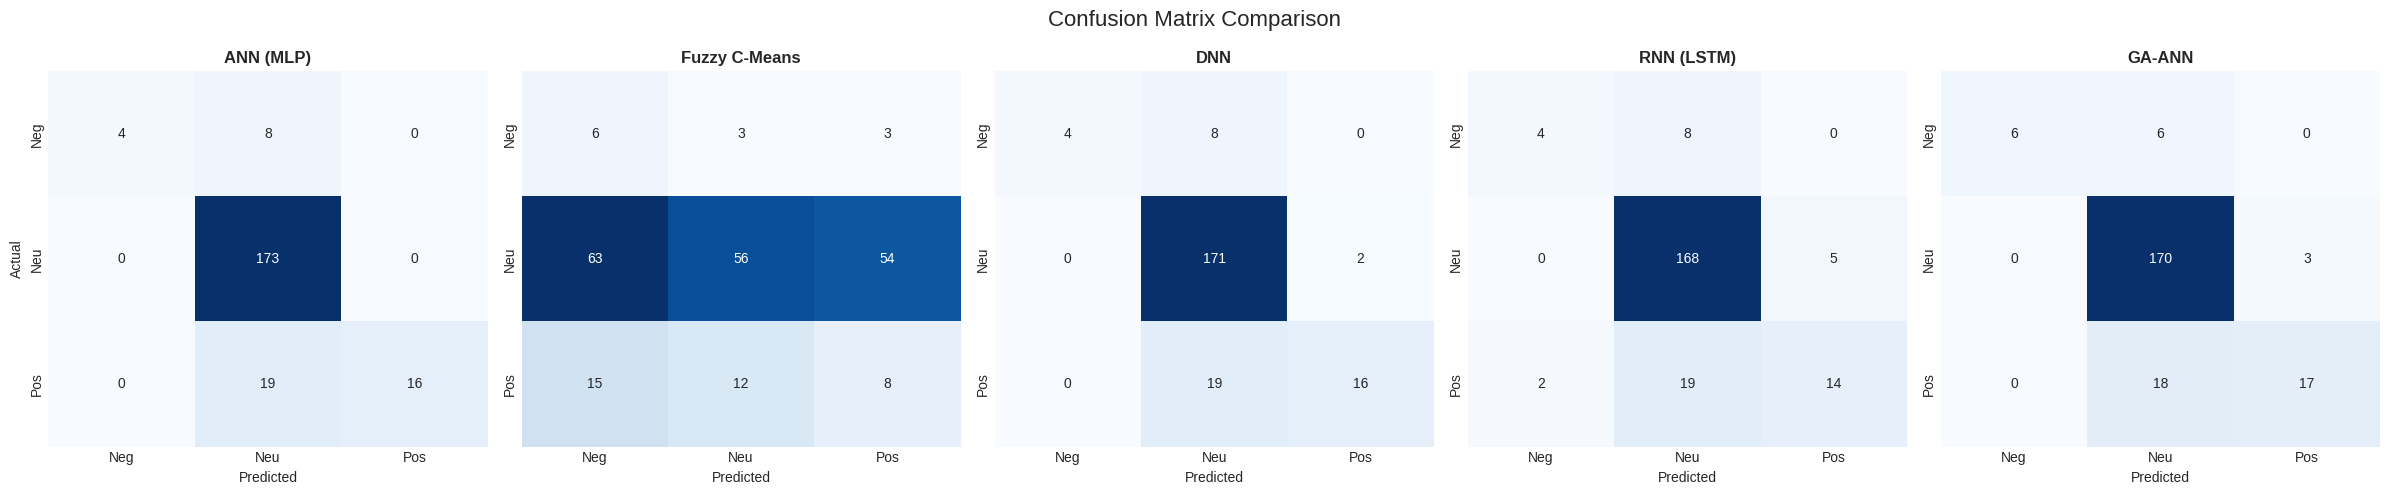

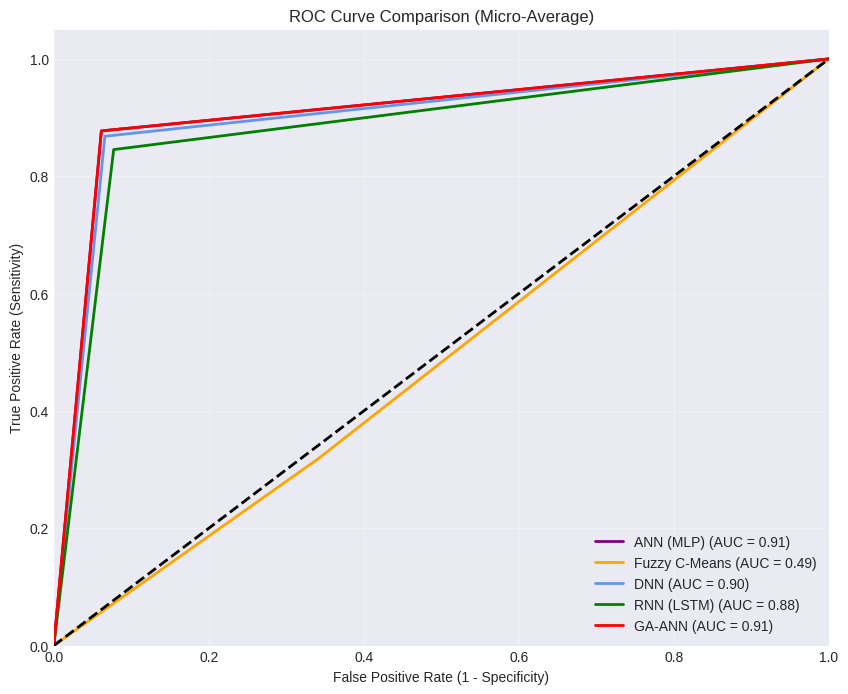

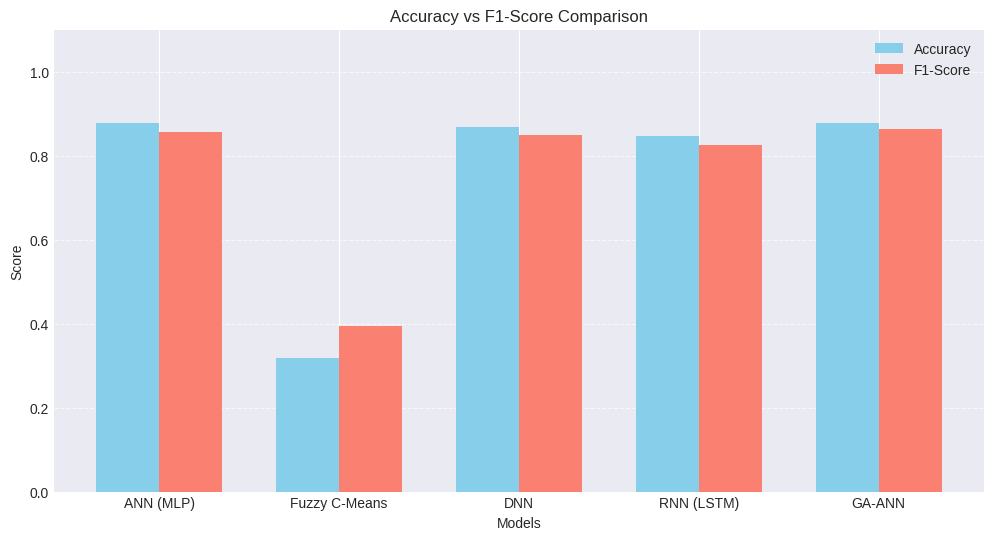

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# 1. Setup Data
# ------------------------------------------------
model_names = ['ANN (MLP)', 'Fuzzy C-Means', 'DNN', 'RNN (LSTM)', 'GA-ANN']
# Ensure these variables exist from your previous training cells
predictions_list = [ann_preds, fuzzy_final_predictions, dnn_final_predictions, rnn_final_predictions, ga_ann_preds]
y_true = y_test

# 2. Metric Summary Table & Text Reports
# ------------------------------------------------
results_list = []
print("--- DETAILED CLASSIFICATION REPORTS ---\n")

for name, pred in zip(model_names, predictions_list):
    # Calculate aggregate metrics
    acc = accuracy_score(y_true, pred)
    f1 = f1_score(y_true, pred, average='weighted')
    report = classification_report(y_true, pred, output_dict=True)

    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': f1
    })

    # Print the full text report
    print(f"[{name}]")
    print(classification_report(y_true, pred, target_names=['Negative', 'Neutral', 'Positive']))
    print("-" * 60)

# Create and display comparison table
results_df = pd.DataFrame(results_list)
print("\n--- PERFORMANCE SUMMARY TABLE ---")
print(results_df.round(4).to_string(index=False))

# 3. Visualization: Confusion Matrices
# ------------------------------------------------
print("\n--- GENERATING GRAPHS ---")
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for i, (pred, name) in enumerate(zip(predictions_list, model_names)):
    cm = confusion_matrix(y_true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    if i == 0: axes[i].set_ylabel('Actual')
    axes[i].set_xticklabels(['Neg', 'Neu', 'Pos'])
    axes[i].set_yticklabels(['Neg', 'Neu', 'Pos'])

plt.suptitle('Confusion Matrix Comparison', fontsize=16)
plt.tight_layout()
plt.savefig('final_confusion_matrices.png')
plt.show()

# 4. Visualization: ROC Curves (Micro-Average)
# ------------------------------------------------
# Binarize labels for Multi-class ROC
y_test_bin = label_binarize(y_true, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))
colors = cycle(['purple', 'orange', 'cornflowerblue', 'green', 'red'])

for pred, name, color in zip(predictions_list, model_names, colors):
    pred_bin = label_binarize(pred, classes=[0, 1, 2])

    # Compute Micro-Average ROC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), pred_bin.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve Comparison (Micro-Average)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('final_roc_curve.png')
plt.show()

# 5. Visualization: Accuracy vs F1 Score Bar Chart
# ------------------------------------------------
plt.figure(figsize=(12, 6))
x = np.arange(len(model_names))
width = 0.35

plt.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='skyblue')
plt.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', color='salmon')

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Accuracy vs F1-Score Comparison')
plt.xticks(x, model_names)
plt.legend()
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('accuracy_f1_bar.png')
plt.show()